In [2]:
import os
import sys

PROJECT_NAME = 'practice-customer-churn-project'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'/content/drive/My Drive/Data Science/PnTDS/04_Projects/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'G:/My Drive/Data Science/PnTDS/04_Projects/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: G:\My Drive\Data Science\PnTDS\04_Projects\practice-customer-churn-project


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
path = os.path.join("dataset", "processed", "telco_churn_clean.csv")

df = pd.read_csv(path)

print(f"Data loaded from {path}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Data loaded from dataset\processed\telco_churn_clean.csv
Rows: 7043, Columns: 21


In [41]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

*1. Line Chart*

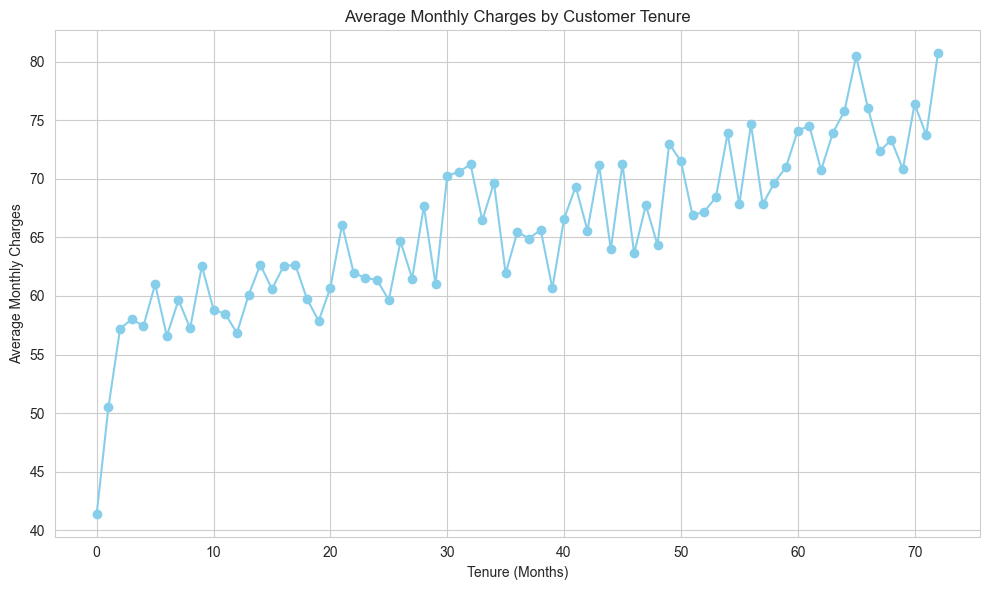

In [60]:
grouped_tenure = df.groupby("tenure")
mean_charges_by_tenure = grouped_tenure["MonthlyCharges"].mean()
line_data = mean_charges_by_tenure.reset_index()

plt.plot(line_data["tenure"], line_data["MonthlyCharges"], color = "skyblue", marker = "o")
plt.title("Average Monthly Charges by Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Average Monthly Charges")

plt.tight_layout()
plt.savefig(os.path.join("outputs", "visualization", "line_chart.png"))

plt.show()

*2. Bar Chart*

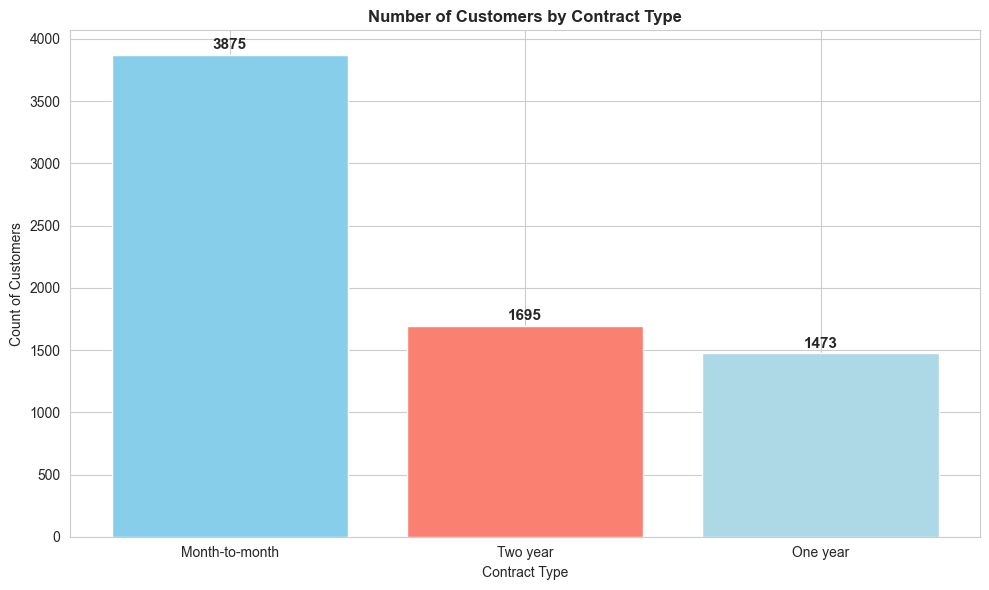

In [59]:
fig, ax = plt.subplots()
colors = ["skyblue", "salmon", "lightblue"]

contract_count = df["Contract"].value_counts()
contract_data = contract_count.reset_index()
contract_data.columns = ['ContractType', 'CustomerCount']

bars = ax.bar(contract_data['ContractType'], contract_data['CustomerCount'], color = colors)
ax.set_title("Number of Customers by Contract Type", fontweight = "bold")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Count of Customers")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 20, f"{int(height)}", ha = "center", va = "bottom", fontsize = 11, fontweight = "bold")

plt.tight_layout()
plt.savefig(os.path.join("outputs", "visualization", "bar_chart.png"))

plt.show()

*3. Pie Chart*

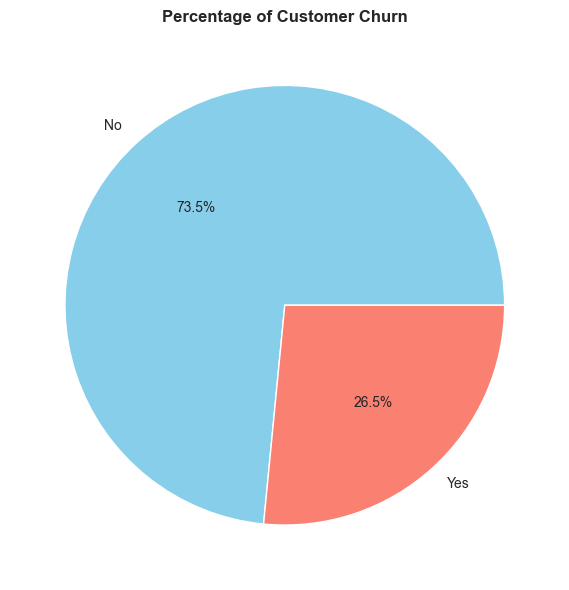

In [ ]:
churn_count = df["Churn"].value_counts()
churn_data = churn_count.reset_index()
churn_data.columns = ["ChurnStatus", "Count"]

plt.pie(churn_data["Count"], 
        labels = churn_data["ChurnStatus"], 
        autopct="%1.1f%%", 
        colors=["skyblue", "salmon"])
plt.title("Percentage of Customer Churn", fontweight = "bold")

plt.tight_layout()
plt.savefig(os.path.join("outputs", "visualization", "pie_chart.png"))
plt.show()